In [16]:
import numpy as np
import multiprocess as mp
from multiprocess import Process
import matplotlib.pyplot as plt

### Section 9.2.1

In [3]:

# If no causal bounds are provided, the algorithm is the same as the classical UCB
# If causal bounds are provided, the algorithm performs clipping of the UCB estimates
def mab_ucb(mab_env, lower=None, upper=None, timesteps=10000):
    if lower is not None or upper is not None:
        if not isinstance(lower, np.ndarray) or lower.shape != (2,) or \
            not isinstance(upper, np.ndarray) or upper.shape != (2,):
            raise ValueError("lower and upper must be numpy arrays of size 2")
            
    rewards_by_arm = np.zeros(2)
    counts_by_arm = np.ones(2) # avoid division by 0
    rewards_over_time = []
    for t in range(timesteps):
        _, info = mab_env.reset()
        ucb_estimates = rewards_by_arm / counts_by_arm + np.sqrt(np.log(1e4) / counts_by_arm)
        if lower is not None and upper is not None:
            ucb_estimates = np.clip(ucb_estimates, lower, upper)
        action = np.argmax(ucb_estimates)
        _, y, terminated, truncated, info = mab_env.do(action)
        rewards_over_time.append(y)
        rewards_by_arm[action] += y
        counts_by_arm[action] += 1
    return rewards_over_time

In [9]:
# Directly transfers observational data to experimental data
def mab_ucb_direct_transfer(mab_env, do_timesteps=10000, see_timesteps=5000):        
    rewards_by_arm = np.zeros(2)
    counts_by_arm = np.ones(2) # avoid division by 0
    rewards_over_time = []
    # initialize UCB counts with observational data
    for t in range(see_timesteps):
        _, info = mab_env.reset()
        x, _, y, terminated, truncated, info = mab_env.see()
        rewards_by_arm[x] += y
        counts_by_arm[x] += 1
        
    for t in range(do_timesteps):
        _, info = mab_env.reset()
        ucb_estimates = rewards_by_arm / counts_by_arm + np.sqrt(np.log(1e4) / counts_by_arm)
        action = np.argmax(ucb_estimates)
        _, y, terminated, truncated, info = mab_env.do(action)
        rewards_over_time.append(y)
        rewards_by_arm[action] += y
        counts_by_arm[action] += 1
    return rewards_over_time

In [20]:
from causal_gym.envs.mab_example import MABExamplePCH

def run_ucb_simulation(_):
    mab_env = MABExamplePCH(delta=0.3)
    do_timesteps = 10000
    ucb_rewards = mab_ucb(mab_env, timesteps=do_timesteps)
    # optimal arm choice is arm 0, with expected reward 0.4
    optimum_rewards = np.ones(do_timesteps)*0.4
    ucb_regret = optimum_rewards - ucb_rewards
    return np.cumsum(ucb_regret)

n_cores = mp.cpu_count()
pool = mp.Pool(processes=n_cores)
all_ucb_regrets = pool.map(run_ucb_simulation, range(1000))
mean_ucb_regret = np.mean(all_ucb_regrets, axis=0)

pool.close()
pool.join()


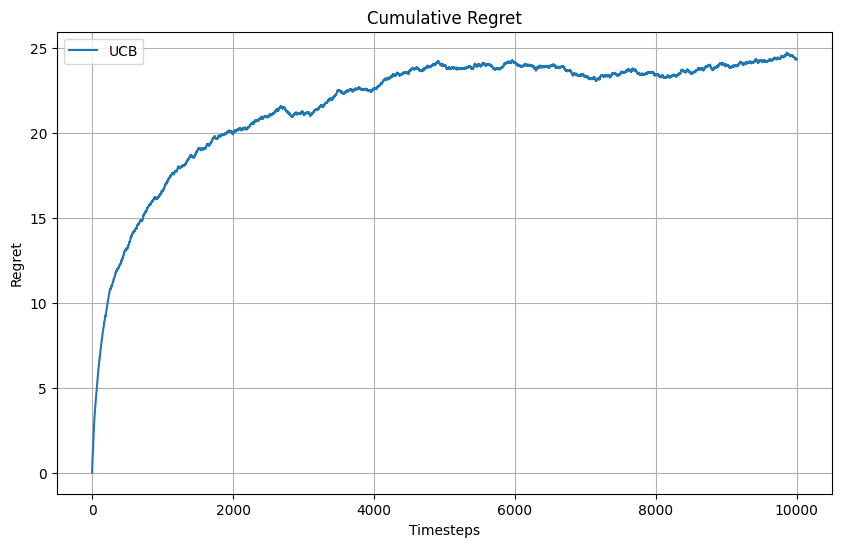

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(mean_ucb_regret)), mean_ucb_regret, label='UCB')
plt.xlabel('Timesteps')
plt.ylabel('Regret')
plt.title('Cumulative Regret')
plt.grid(True)
plt.legend()
plt.show()

In [22]:
from causal_gym.envs.mab_example import MABExamplePCH

# collect 5000 observational datapoints to estimate E[Y|x] and P(x)
total_by_arm, reward_by_arm = np.zeros(2), np.zeros(2)
for _ in range(5000):
    mab_env = MABExamplePCH(delta=0.3)
    _, info = mab_env.reset()
    x, _, y, terminated, truncated, info = mab_env.see()
    total_by_arm[x] += 1
    reward_by_arm[x] += y
expected_reward_by_arm = reward_by_arm / total_by_arm
prob_of_arm = total_by_arm / 5000

# calculate lower and upper bounds for E[Y|do(x)]
lower_bound = expected_reward_by_arm*prob_of_arm
upper_bound = expected_reward_by_arm*prob_of_arm + (1-prob_of_arm)
print("Lower Bound: ", lower_bound, "Upper Bound: ", upper_bound)

def run_causal_ucb_simulation(_):
    mab_env = MABExamplePCH(delta=0.3)
    do_timesteps = 10000
    ucb_rewards = mab_ucb(mab_env, lower=lower_bound, upper=upper_bound, timesteps=do_timesteps)
    # optimal arm choice is arm 0, with expected reward 0.4
    optimum_rewards = np.ones(do_timesteps)*0.4
    ucb_regret = optimum_rewards - ucb_rewards
    return np.cumsum(ucb_regret)

n_cores = mp.cpu_count()
pool = mp.Pool(processes=n_cores)
all_causal_ucb_regrets = pool.map(run_causal_ucb_simulation, range(1000))
mean_causal_ucb_regret = np.mean(all_causal_ucb_regrets, axis=0)

pool.close()
pool.join()


Lower Bound:  [0.     0.1052] Upper Bound:  [0.8078 0.2974]


In [23]:
def run_ucb_direct_transfer_simulation(_):
    mab_env = MABExamplePCH(delta=0.3)
    do_timesteps = 10000
    # match the number of observational datapoints as causal UCB above
    ucb_rewards = mab_ucb_direct_transfer(mab_env, do_timesteps=do_timesteps, see_timesteps=5000)
    # optimal arm choice is arm 0, with expected reward 0.4
    optimum_rewards = np.ones(do_timesteps)*0.4
    ucb_regret = optimum_rewards - ucb_rewards
    return np.cumsum(ucb_regret)

n_cores = mp.cpu_count()
pool = mp.Pool(processes=n_cores)
all_ucb_direct_transfer_regrets = pool.map(run_ucb_direct_transfer_simulation, range(1000))
mean_ucb_direct_transfer_regret = np.mean(all_ucb_direct_transfer_regrets, axis=0)

pool.close()
pool.join()

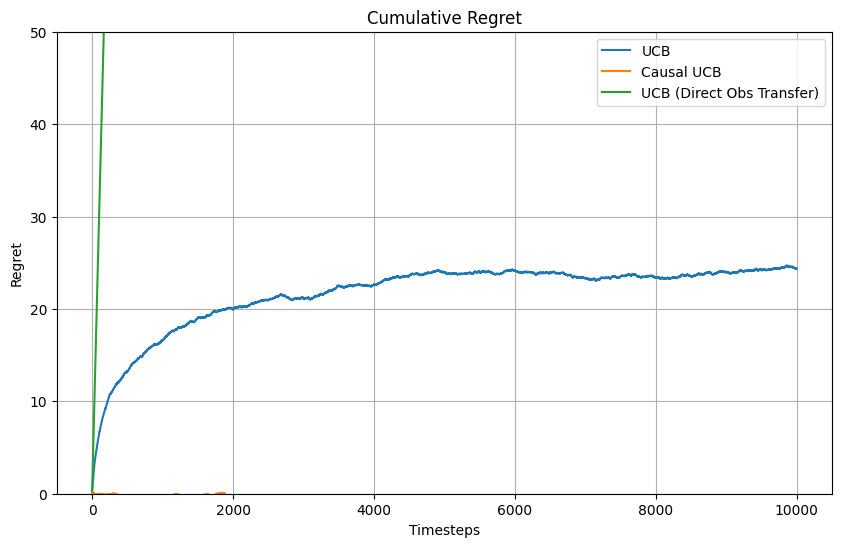

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(mean_ucb_regret)), mean_ucb_regret, label='UCB')
plt.plot(range(len(mean_causal_ucb_regret)), mean_causal_ucb_regret, label='Causal UCB')    
plt.plot(range(len(mean_ucb_direct_transfer_regret)), mean_ucb_direct_transfer_regret, label='UCB (Direct Obs Transfer)')
plt.xlabel('Timesteps')
plt.ylabel('Regret')
plt.title('Cumulative Regret')
plt.grid(True)
plt.legend()
plt.ylim(0, 50)
plt.show()

### Section 9.2.2

In [ ]:
# Calculate argmax_x2 and Q(s1, x1, s2)
def get_argmax_x2(delta, Q_full, visit_counts):
    Q2 = np.zeros((2, 2, 2)) # Q values for each combination of s1, x1, s2
    argmax_x2 = np.zeros((2, 2, 2), dtype=np.int8) # argmax_x2 for each Q(s1, x1, s2, x2)
    for s1 in [0, 1]:
        for x1 in [0, 1]:
            for s2 in [0, 1]:
                argmax_x2, argmax_Q = -1, -np.inf
                for x2 in [0, 1]:
                    width = get_confidence_width(delta, 2, visit_counts[s1, x1, s2, x2])
                    if Q_full[s1, x1, s2, x2] + width > argmax_Q:
                        argmax_x2 = x2  
                        argmax_Q = Q_full[s1, x1, s2, x2] + width
                Q2[s1, x1, s2] = argmax_Q
                argmax_x2[s1, x1, s2] = argmax_x2
    return argmax_x2, Q2

def get_argmax_x1(delta, Q_2, visit_counts):
    argmax_x1 = np.zeros((2,), dtype=np.int8)
    for s1 in [0, 1]:
        argmax_x1, argmax_Q = -1, -np.inf
        for x1 in [0, 1]:
            width = get_confidence_width(delta, 1, visit_counts[s1, x1, :, :].sum())
            # TODO: Solve linear program 
    return argmax_x1

# Calculate confidence width (visit count refers to number of times state-action sequence has been visited)
def get_confidence_width(delta, t, visit_count):
    assert (t in [1, 2]), 't must be 1 or 2'
    horizon = 2
    dim_s = 2
    dim_s_union_x = 4
    if t < 2:
        return np.sqrt(2*dim_s*np.log(4*horizon*dim_s_union_x/delta)/visit_count)
    else:
        return np.sqrt(np.log(8*horizon*dim_s_union_x/delta)/(2*visit_count))